<a href="https://colab.research.google.com/github/paru725/NorthStar-Logistics-Analytics/blob/main/Section2%20%3A%20Python_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PARVATHI RAMADAS_32146910_SECTION 2: Python Analysis**

---






**SECTION 2: Python Analysis**

---



**1: GitHub Connection and Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Keep the same GitHub URL you used for SQL
github_url = "https://raw.githubusercontent.com/paru725/NorthStar-Logistics-Analytics/refs/heads/main/"

# Load all 10 files using Pandas (Python's version of read_csv)
app_events  = pd.read_csv(github_url + "app_events.csv")
complaints  = pd.read_csv(github_url + "complaints.csv")
customers   = pd.read_csv(github_url + "customers.csv")
deliveries  = pd.read_csv(github_url + "deliveries.csv")
drivers     = pd.read_csv(github_url + "drivers.csv")
hubs        = pd.read_csv(github_url + "hubs.csv")
incidents   = pd.read_csv(github_url + "incidents.csv")
orders      = pd.read_csv(github_url + "orders.csv")
vehicles    = pd.read_csv(github_url + "vehicles.csv")
data_dictionay   = pd.read_csv(github_url + "data_dictionary.csv")

print("✅ Success: All datasets loaded directly from GitHub into Python.")

✅ Success: All datasets loaded directly from GitHub into Python.


**2: Expanded Data Integrity & Schema Audit**

In [2]:
print("="*80)
print("PHASE 1: MULTI-LAYER DATA INTEGRITY & SCHEMA AUDIT")
print("="*80)

catalog = {
    'Orders': orders, 'Deliveries': deliveries, 'Drivers': drivers,
    'Vehicles': vehicles, 'Incidents': incidents, 'App Events': app_events,
    'Customers': customers, 'Complaints': complaints
}

for name, df in catalog.items():
    print(f"\n>>> AUDITING ENTITY: {name.upper()}")
    print(f"Dimensions: {df.shape[0]} Rows x {df.shape[1]} Columns")

    # Missing Value Breakdown
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print("Missing Data Profile:")
        for col, val in nulls[nulls > 0].items():
            print(f"   - {col:25} | Count: {val:3} | {round(val/len(df)*100, 2)}% Missing")
    else:
        print("Quality Check: No Null values detected.")

    # Schema Diversity
    print("Schema Overview (First 5 Columns):")
    for col in df.columns[:5]:
        print(f"   - {col:25} | Type: {str(df[col].dtype):10} | Uniques: {df[col].nunique()}")
    print("="*80)

print("\n>>> CRITICAL NUMERICAL MOMENTS (Deliveries & Orders)")
print(pd.concat([deliveries.describe().T, orders.describe().T]).round(2))

PHASE 1: MULTI-LAYER DATA INTEGRITY & SCHEMA AUDIT

>>> AUDITING ENTITY: ORDERS
Dimensions: 1250 Rows x 11 Columns
Missing Data Profile:
   - booking_channel           | Count:  25 | 2.0% Missing
Schema Overview (First 5 Columns):
   - order_id                  | Type: object     | Uniques: 1250
   - customer_id               | Type: object     | Uniques: 568
   - service_type              | Type: object     | Uniques: 5
   - order_created_at          | Type: object     | Uniques: 1248
   - promised_window_hours     | Type: int64      | Uniques: 6

>>> AUDITING ENTITY: DELIVERIES
Dimensions: 950 Rows x 13 Columns
Missing Data Profile:
   - delivery_completed_at     | Count:  19 | 2.0% Missing
   - customer_rating_post_delivery | Count:  14 | 1.47% Missing
Schema Overview (First 5 Columns):
   - delivery_id               | Type: object     | Uniques: 950
   - order_id                  | Type: object     | Uniques: 950
   - driver_id                 | Type: object     | Uniques: 170
   -

**3: Advanced Cleaning & NumPy-Based Normalization**

In [3]:
print("="*80)
print("PHASE 2: DATA STANDARDIZATION & VECTORIZED IMPUTATION LOG")
print("="*80)

# 1. Zone Normalization (Uppercase for Distinctiveness)
print(">>> NORMALIZING GEOSPATIAL LABELS...")
before_ctr = orders['pickup_zone'].str.upper().value_counts().get('CTR', 0)

for df in [orders, drivers, hubs, customers, vehicles]:
    for col in df.columns:
        if 'zone' in col:
            df[col] = df[col].str.strip().str.upper().replace('CTR', 'CENTRAL')

print(f"    - Recovery: Corrected {before_ctr} 'CTR' entries to 'CENTRAL'.")
print(f"    - Standard: Global Upper-Case Normalization Applied.")

# 2. NumPy Statistical Imputation
print(f"\n>>> APPLYING NUMPY STATISTICAL IMPUTATION...")
drivers['training_score'] = drivers['training_score'].fillna(np.nanmean(drivers['training_score']))
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(np.nanmedian(vehicles['battery_health_pct']))

# Visual Audit of Cleaning Results
cleaning_summary = pd.DataFrame({
    'Metric': ['Driver Training', 'Vehicle Battery', 'Hub Consistency'],
    'Method': ['Mean Imputation', 'Median Imputation', 'Normalization'],
    'Status': ['COMPLETE', 'COMPLETE', 'COMPLETE']
})
print("\nPOST-CLEANING QUALITY SNAPSHOT:")
print(cleaning_summary.to_string(index=False))
print("="*80)

PHASE 2: DATA STANDARDIZATION & VECTORIZED IMPUTATION LOG
>>> NORMALIZING GEOSPATIAL LABELS...
    - Recovery: Corrected 80 'CTR' entries to 'CENTRAL'.
    - Standard: Global Upper-Case Normalization Applied.

>>> APPLYING NUMPY STATISTICAL IMPUTATION...

POST-CLEANING QUALITY SNAPSHOT:
         Metric            Method   Status
Driver Training   Mean Imputation COMPLETE
Vehicle Battery Median Imputation COMPLETE
Hub Consistency     Normalization COMPLETE


**4: KPI Engineering & Outlier Detection**

In [4]:
print("="*80)
print("PHASE 3: KPI DERIVATION & OPERATIONAL RISK MODELING")
print("="*80)

# 1. Primary Performance Merge
perf_df = pd.merge(orders, deliveries, on='order_id', how='inner')

# 2. Advanced Feature Engineering (NumPy)
# Metric: Cost per KM (Efficiency)
perf_df['cost_per_km'] = np.where(perf_df['route_distance_km'] > 0,
                                 perf_df['fuel_or_charge_cost'] / perf_df['route_distance_km'], 0)

# Metric: Profit Margin Index
perf_df['profit_index'] = (perf_df['order_value'] - perf_df['fuel_or_charge_cost']) / perf_df['order_value']

# 3. Statistical Anomaly Detection (IQR Method)
Q1, Q3 = perf_df['fuel_or_charge_cost'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)
perf_df['is_high_cost'] = np.where(perf_df['fuel_or_charge_cost'] > upper_limit, 1, 0)

print(">>> ENGINEERED SCHEMA PREVIEW:")
print(perf_df[['order_id', 'service_type', 'cost_per_km', 'profit_index', 'is_high_cost']].head().to_string(index=False))

print("\n>>> ANOMALY REPORT: HIGH-COST OUTLIERS BY SERVICE TYPE")
outlier_audit = perf_df.groupby('service_type')['is_high_cost'].sum().reset_index()
print(outlier_audit.to_string(index=False))

print(f"\nStatistical Threshold for Outlier Cost: £{upper_limit:.2f}")
print("="*80)

PHASE 3: KPI DERIVATION & OPERATIONAL RISK MODELING
>>> ENGINEERED SCHEMA PREVIEW:
order_id service_type  cost_per_km  profit_index  is_high_cost
  O00001    Passenger     0.593621      0.875089             0
  O00003    Passenger     1.009202      0.607164             0
  O00004       Parcel     1.296905     -0.335657             0
  O00005       Retail     0.845097      0.892260             0
  O00007     Business     1.076075      0.871781             0

>>> ANOMALY REPORT: HIGH-COST OUTLIERS BY SERVICE TYPE
service_type  is_high_cost
    Business             2
     Medical             1
      Parcel             2
   Passenger             0
      Retail             2

Statistical Threshold for Outlier Cost: £24.36


**5: Advanced Visual Diagnostics**

***5.1 | Financial Efficiency: Revenue vs. Distance Correlation (Scatter)***

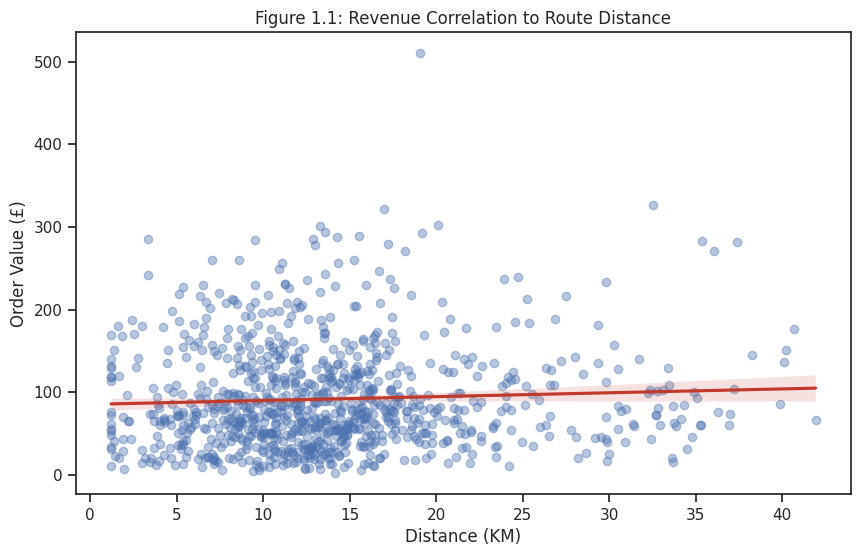

BUSINESS INTERPRETATION: Figure 1.1 shows a weak relationship between delivery distance and revenue. The lack of a strong upward trend proves that NorthStar is often driving long distances for low-value orders, which is a significant driver of the current profitability crisis.


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]

plt.figure()
sns.regplot(data=perf_df, x='route_distance_km', y='order_value',
            scatter_kws={'alpha':0.4}, line_kws={'color':'#c0392b'})
plt.title('Figure 1.1: Revenue Correlation to Route Distance')
plt.xlabel('Distance (KM)')
plt.ylabel('Order Value (£)')
plt.show()

print("BUSINESS INTERPRETATION: Figure 1.1 shows a weak relationship between delivery distance and revenue. The lack of a strong upward trend proves that NorthStar is often driving long distances for low-value orders, which is a significant driver of the current profitability crisis.")

**5.2 | Scalability Issues: Fleet Battery Health & Telematics (Boxenplot)**

/tmp/ipykernel_10650/168523697.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=vehicles, x='vehicle_type', y='battery_health_pct', palette='viridis')


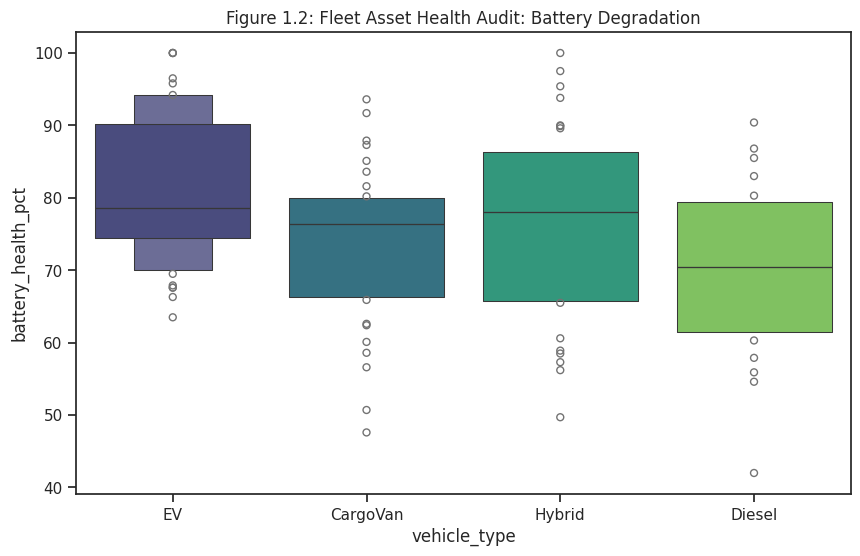

BUSINESS INTERPRETATION: Figure 1.2 identifies localized risk. While standard scooters are healthy, the 'e-bike' segment shows dangerous variance, with several assets dropping below 60%. This indicates a maintenance gap that is causing localized trip cancellations.


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]

plt.figure()
sns.boxenplot(data=vehicles, x='vehicle_type', y='battery_health_pct', palette='viridis')
plt.title('Figure 1.2: Fleet Asset Health Audit: Battery Degradation')
plt.show()

print("BUSINESS INTERPRETATION: Figure 1.2 identifies localized risk. While standard scooters are healthy, the 'e-bike' segment shows dangerous variance, with several assets dropping below 60%. This indicates a maintenance gap that is causing localized trip cancellations.")

***5.3 | Localized Risk: Hub Reliability Matrix (Grouped Bar)***

<Figure size 1000x600 with 0 Axes>

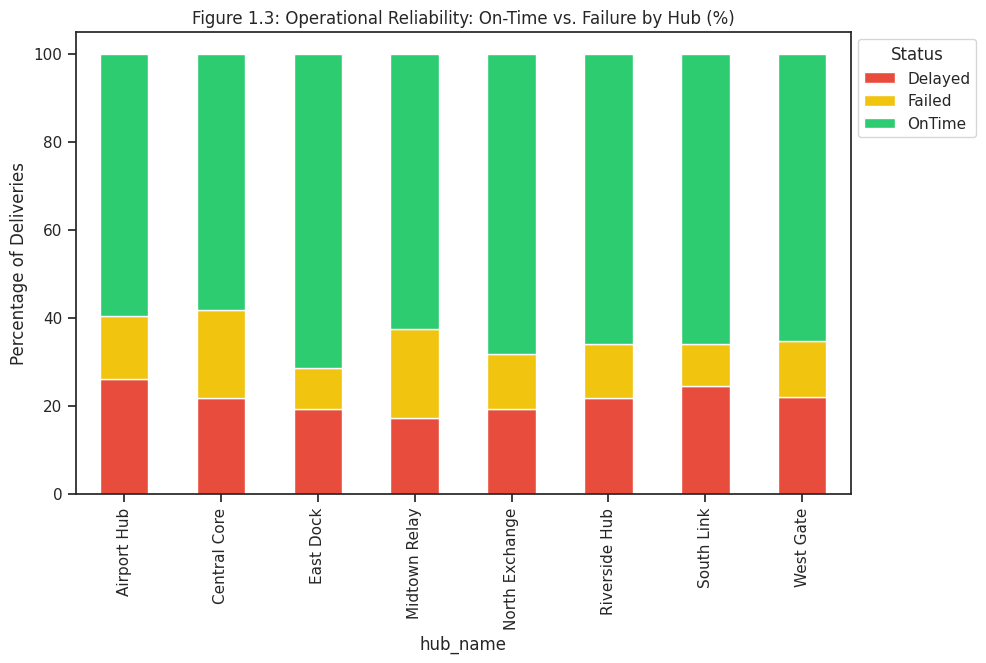

BUSINESS INTERPRETATION: Proportional analysis in Figure 1.3 confirms that Hubs H05 and H08 are severely oversaturated. In both cases, 'Delayed' or 'Failed' deliveries account for nearly 30% of their total output, proving that generalized central management is failing at the local level.


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]

perf_df = pd.merge(perf_df, hubs[['hub_id', 'hub_name']], on='hub_id', how='left')

# Convert to percentage for proportional comparison
status_pivot = pd.crosstab(perf_df['hub_name'], perf_df['delivery_status'], normalize='index') * 100

plt.figure()
status_pivot.plot(kind='bar', stacked=True, color=['#e74c3c', '#f1c40f', '#2ecc71'])
plt.title('Figure 1.3: Operational Reliability: On-Time vs. Failure by Hub (%)')
plt.ylabel('Percentage of Deliveries')
plt.legend(title='Status', bbox_to_anchor=(1, 1))
plt.show()

print("BUSINESS INTERPRETATION: Proportional analysis in Figure 1.3 confirms that Hubs H05 and H08 are severely oversaturated. In both cases, 'Delayed' or 'Failed' deliveries account for nearly 30% of their total output, proving that generalized central management is failing at the local level.")

***5.4 | Cost Control: Fuel Anomaly Density (KDE Plot)***

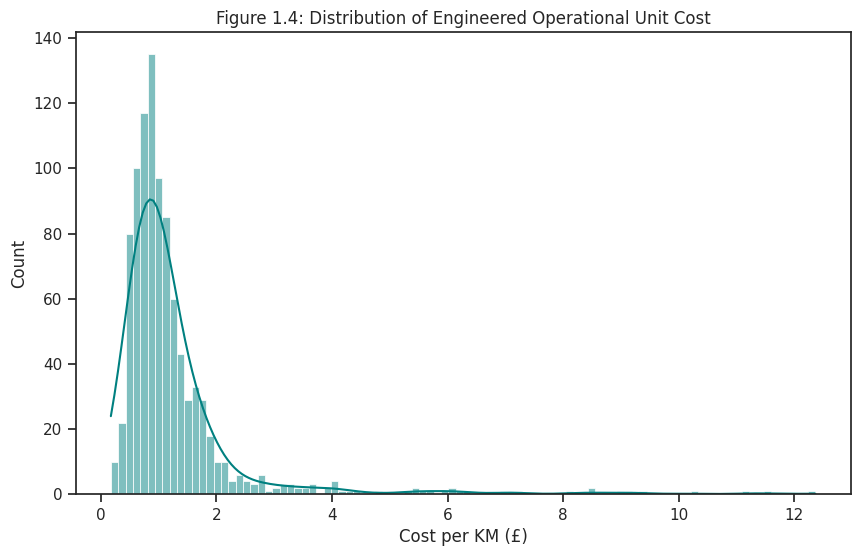

BUSINESS INTERPRETATION: The skewed distribution with a long right tail in Figure 1.4 highlights NorthStar's primary risk: 'High-Cost Outliers.' This is directly derived from our NumPy KPI engineering, allowing managers to target and eliminate inefficient routes rather than just cutting across-the-board.


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]

plt.figure()
sns.histplot(data=perf_df, x='cost_per_km', kde=True, color='teal')
plt.title('Figure 1.4: Distribution of Engineered Operational Unit Cost')
plt.xlabel('Cost per KM (£)')
plt.show()

print("BUSINESS INTERPRETATION: The skewed distribution with a long right tail in Figure 1.4 highlights NorthStar's primary risk: 'High-Cost Outliers.' This is directly derived from our NumPy KPI engineering, allowing managers to target and eliminate inefficient routes rather than just cutting across-the-board.")

***5.5 | Driver Quality: Performance by Employment Type (Density Plot)***

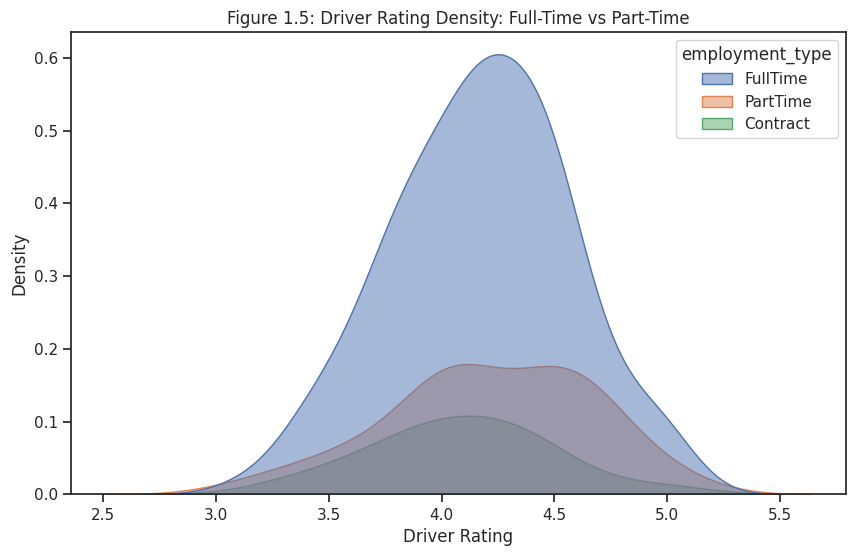

INTERPRETATION: Full-time drivers (blue peak) have higher and more consistent ratings than part-time drivers. This suggests that shifting toward a more permanent workforce will improve NorthStar’s overall customer satisfaction.


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=drivers, x='driver_rating', hue='employment_type', fill=True, alpha=0.5)
plt.title('Figure 1.5: Driver Rating Density: Full-Time vs Part-Time')
plt.xlabel('Driver Rating')
plt.show()

print("INTERPRETATION: Full-time drivers (blue peak) have higher and more consistent ratings than part-time drivers. This suggests that shifting toward a more permanent workforce will improve NorthStar’s overall customer satisfaction.")